# Flowline: comparing front treatments (HO)

A marine-terminating glacier along a flowline: grounded on a bed that deepens toward the sea, crossing sea level, and ungrounding into a floating tongue. (1) It is first spun up for 100 years with a nonmoving front, to a steady state. From there, it is run for 20 years in three ways: (2) moving front without calving, (3) moving front with a rate law (calving proportional to the submerged thickness), and (4) moving front with a position law (any floating ice calves). Basal drag is proportional to the fraction above flotation, and the tongue melts at its base at 2 m/a throughout.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm

from model import model
from issm_helper import *

## Geometry and parameters

Basal drag is proportional to the fraction above flotation: $\tau_b = C^2 f_{af} |u_b|^{1/m}$. It equals Weertman drag where the ice is well grounded and collapses toward flotation.

In [2]:
x_nodes = np.arange(0, 50e3 + 1, 250) #node positions along the flowline (m)
md = flowline_mesh(model(), x_nodes)
x = md.mesh.x

x_t = 30e3 #initial terminus position (m)
bed = 100 - 0.01*x #from 100 m to -525 m
H_0 = 500 

C = 2200 #Weertman C where the ice is well grounded
ϱ = md.materials.rho_ice/md.materials.rho_water

def friction(md):
    '''Weertman C scaled so that basal drag is proportional to the fraction above flotation'''
    H = md.geometry.thickness
    f_af = np.clip((md.geometry.base + ϱ*H)/H, 0.01, 1) #fraction above flotation (sea level at 0)
    return C*np.sqrt(f_af) 

initialization_params = {'approximation': 'HO',
                         'vertical_layers': 5,
                         'temperature': 263.15,
                         'friction': C, #replaced by friction(md) at every solve
                         'basal_melt': 2, #under floating ice (m/a)
                         'bed': bed,
                         'thickness': H_0,
                         'ice_levelset': x - x_t,
                         'spcvx': dirichlet(md, (x == 0, 240)),
                         'spcthickness': dirichlet(md, (x == 0, H_0))}

Δt = 0.5 #time step (a)
model_time = 20 #years
num_steps = int(model_time/Δt)

Δt_spinup = 1.0
spinup_time = 100 
spinup_steps = int(spinup_time/Δt_spinup)

### (1) Spin-up with a nonmoving front

Reach steady state before running other experiments. 

In [3]:
md1 = flowline_mesh(model(), x_nodes)
md1 = initialize_model(md1, moving_front = False, **initialization_params)

for step in tqdm.trange(spinup_steps):
    u, H_spinup, s = coupled_solve(md1, Δt_spinup, friction = friction(md1))

100%|██████████| 100/100 [01:01<00:00,  1.62it/s]


Each of the runs below starts from a new model with the spun-up thickness and a moving front.

In [4]:
spinup_params = {**initialization_params, 'thickness': H_spinup}

### (2) Moving front, no calving

In [5]:
md2 = flowline_mesh(model(), x_nodes)
md2 = initialize_model(md2, moving_front = True, **spinup_params)

for step in tqdm.trange(num_steps):
    u, H, s = coupled_solve(md2, Δt, friction = friction(md2))

100%|██████████| 40/40 [00:42<00:00,  1.07s/it]


### (3) Moving front, rate law: calving proportional to the submerged thickness

The calving rate is c·d, with d the submerged thickness: the depth of the ice base below sea level. Once the tongue is gone, d is the water depth at a grounded front, so on this bed the front retreats into shallower water, where calving slows.

In [6]:
c = 3.0 #calving rate per metre of submerged thickness (1/a)

md3 = flowline_mesh(model(), x_nodes)
md3 = initialize_model(md3, moving_front = True, **spinup_params)

for step in tqdm.trange(num_steps):
    u = diagnostic_solve(md3, friction = friction(md3))
    d = np.maximum(-md3.geometry.base, 0) #submerged thickness (m), sea level at 0
    rate_law(md3, rate = c*d, extrapolate = True)
    H, s = prognostic_solve(md3, Δt)

100%|██████████| 40/40 [00:31<00:00,  1.26it/s]


### (4) Moving front, position law: anything past the grounding line calves


In [7]:
md4 = flowline_mesh(model(), x_nodes)
md4 = initialize_model(md4, moving_front = True, **spinup_params)

for step in tqdm.trange(num_steps):
    u = diagnostic_solve(md4, friction = friction(md4))
    position_law(md4, forcing = -md4.mask.ocean_levelset, threshold = 0) #calve all floating ice
    H, s = prognostic_solve(md4, Δt)

100%|██████████| 40/40 [00:38<00:00,  1.03it/s]


## Comparison

The spun-up glacier, and the three runs 20 years later, with the surface speed in red (right axis). The dashed line is the terminus, the triangle the grounding line, and the dotted line the initial terminus.

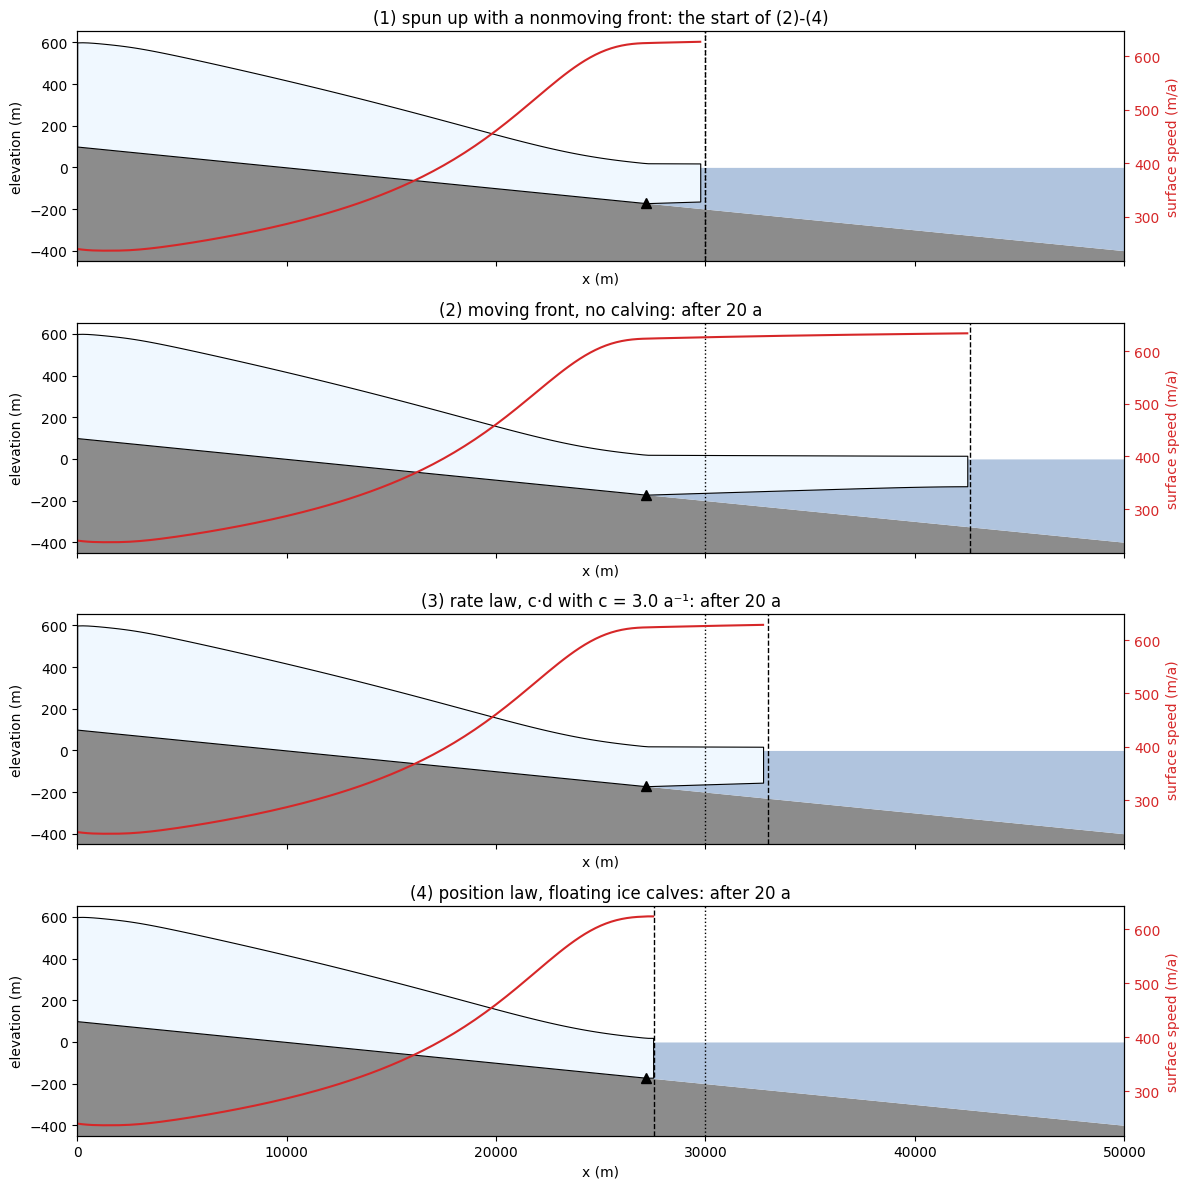

In [8]:
fig, axes = plt.subplots(4, 1, figsize = (12, 12), sharex = True)
for ax, (title, md) in zip(axes, [('(1) spun up with a nonmoving front: the start of (2)-(4)', md1),
                                  ('(2) moving front, no calving: after 20 a', md2),
                                  (f'(3) rate law, c·d with c = {c} a⁻¹: after 20 a', md3),
                                  (f'(4) position law, floating ice calves: after 20 a', md4)]):
    plot_geometry(md, ax = ax, title = title)
    ax.axvline(x_t, color = 'k', linestyle = 'dotted', linewidth = 1) #initial terminus

    x_p, speed = profile(md, np.hypot(md.initialization.vx, md.initialization.vy)) #surface speed (m/a)
    ice = profile(md, md.mask.ice_levelset)[1] < 0
    ax2 = ax.twinx()
    ax2.plot(x_p, np.where(ice, speed, np.nan), color = 'C3')
    # ax2.set_ylim(0, 800)
    ax2.set_ylabel('surface speed (m/a)', color = 'C3')
    ax2.tick_params(axis = 'y', colors = 'C3')
plt.tight_layout()
plt.show()